# Constructing EOS and solving TOV equations beyond General Relativity

This example notebook shows how to construct the equation of state with the metamodel and speed-of-sound extension scheme parametrization used in the paper, as well as solve the TOV equations beyond GR. 

In [1]:
import matplotlib.pyplot as plt
params = {"text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"],
          "xtick.labelsize": 16,
          "ytick.labelsize": 16,
          "axes.labelsize": 16,
          "legend.fontsize": 16,
          "legend.title_fontsize": 16}
plt.rcParams.update(params)

import jax.numpy as jnp
import jax
# from jesterTOV.eos.metamodel.metamodel_CSE import MetaModel_with_CSE_EOS_model
# from jesterTOV.eos.families import construct_family, construct_family_nonGR, construct_family_ST, construct_family_ST_Greci, construct_family_ST_sol, construct_family_eibi
import jesterTOV.utils as utils
import time
from jesterTOV import utils
from jesterTOV.eos.metamodel import MetaModel_EOS_model, MetaModel_with_CSE_EOS_model
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver
# from jesterTOV.tov.eibi import EiBITOVSolver
from jesterTOV.tov.data_classes import EOSData

# Equation of state

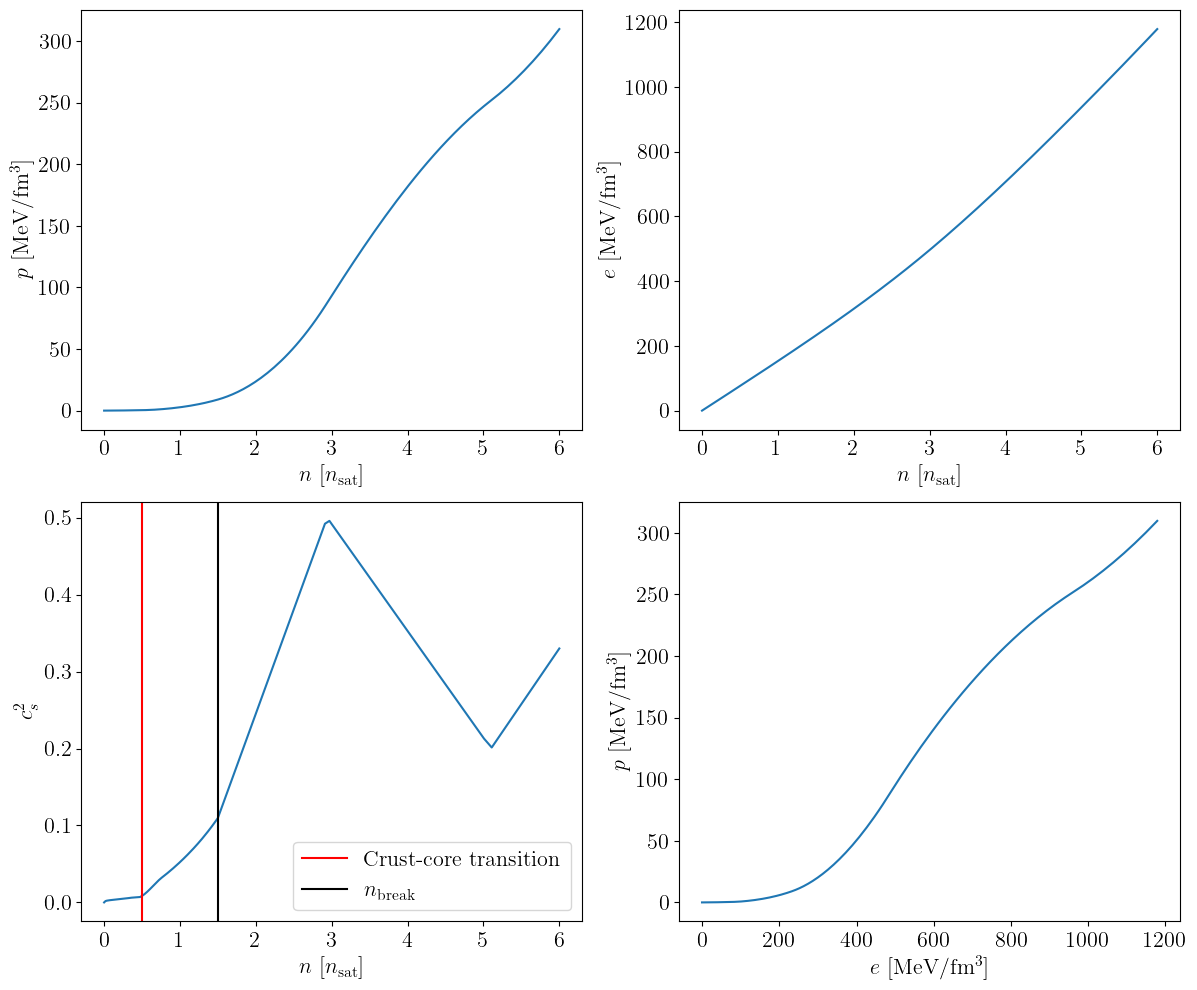

In [2]:
nsat = 0.16 # nuclear saturation density in fm^-3

# Define the EOS object, here we focus on Metamodel with CSE
nmax_nsat = 6.0
nb_CSE=4
eos = MetaModel_with_CSE_EOS_model(nmax_nsat=nmax_nsat, nb_CSE=nb_CSE, nmin_MM_nsat=0.75,ndat_metamodel=80, ndat_CSE=70)

# Define the nuclear empirical parameters (NEPs) -- all in MeV
input_dict = {"E_sat": -16.0, # saturation parameters
            "K_sat": 200.0,
            "Q_sat": 0.0,
            "Z_sat": 0.0,
            "E_sym": 32.0, # symmetry parameters
            "L_sym": 70.0,
            "K_sym": -100.0,
            "Q_sym": 0.0,
            "Z_sym": 0.0,
            "nbreak": 1.5 * nsat,
            }


# Then we extend with some CSE grid points
ngrids = jnp.array([2.0, 3.0, 4.0, 5.0]) * nsat
cs2grids = jnp.array([0.5, 0.4, 0.3, 0.2]) # speed of sound squared at the grid points
# Add CSE grid parameters (normalized positions and cs2 values)
input_dict["n_CSE_0_u"] = ngrids[0]
input_dict["cs2_CSE_0"] = cs2grids[0]
input_dict["n_CSE_1_u"] = ngrids[1]
input_dict["cs2_CSE_1"] = cs2grids[1]
input_dict["n_CSE_2_u"] = ngrids[2]
input_dict["cs2_CSE_2"] = cs2grids[2]
input_dict["n_CSE_3_u"] = ngrids[3]
input_dict["cs2_CSE_3"] = cs2grids[3]
input_dict["n_CSE_4_u"] = nmax_nsat
input_dict["cs2_CSE_4"] = 0.33  # Final cs2 value

# Now create the EOS -- returns a tuple with most useful EOS quantities
eos_output= eos.construct_eos(input_dict)
ns, ps, hs, es, dloge_dlogps, mu, cs2 =  eos_output.ns, eos_output.ps, eos_output.hs, eos_output.es, eos_output.dloge_dlogps, eos_output.mu, eos_output.cs2
# Make a plot
plt.subplots(nrows = 2, ncols = 2, figsize = (12, 10))

# For the plot, let's make some conversions to more common units
ns_plots = ns / utils.fm_inv3_to_geometric / 0.16
es_plots = es / utils.MeV_fm_inv3_to_geometric
ps_plots = ps / utils.MeV_fm_inv3_to_geometric

# p(n)
plt.subplot(221)
plt.plot(ns_plots, ps_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")

# e(n)
plt.subplot(222)
plt.plot(ns_plots, es_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$e$ [MeV/fm$^3$]")

# cs2(n)
plt.subplot(223)
plt.plot(ns_plots, cs2)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$c_s^2$")
plt.axvline(0.5, color = "red", label = "Crust-core transition")
plt.axvline(input_dict["nbreak"] / nsat, color = "black", label = r"$n_{\rm{break}}$")
plt.legend()

# p(e)
plt.subplot(224)
plt.plot(es_plots, ps_plots)
plt.xlabel(r"$e$ [MeV/fm$^3$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.tight_layout()
plt.show() # uncomment to see the EOS
plt.close()

# 1. Neutron stars in Standard Scalar-Tensor Theory

##### Solving the TOV equations to construct an M(R) curve and calculate their tidal deformabilities based on Gastón Creci, Tanja Hinderer, Jan Steinhoff Phys.Rev.D 108 (2023) 12, 124073

Running vmap for scalar-tensor calculations...
Scalar-tensor calculations for 7 beta values finished in 53.4473 seconds.


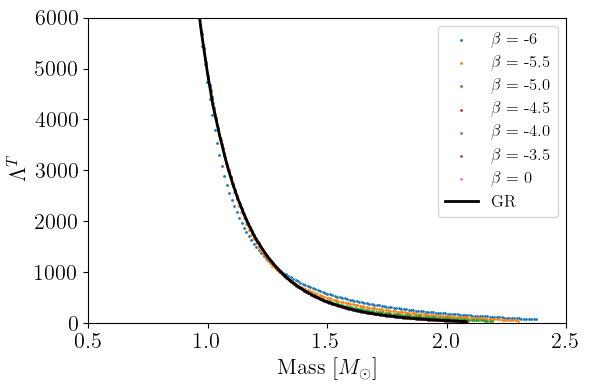

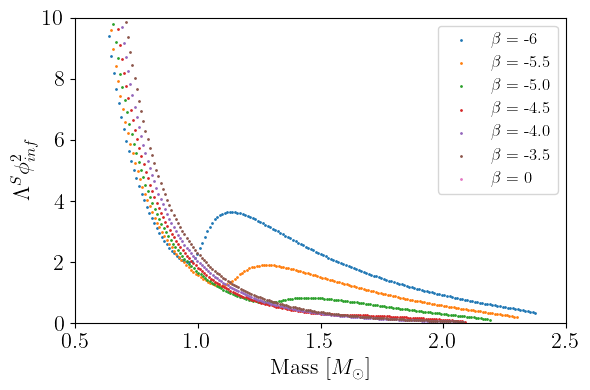

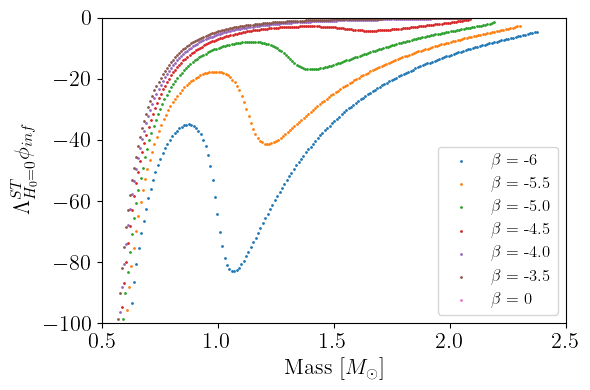

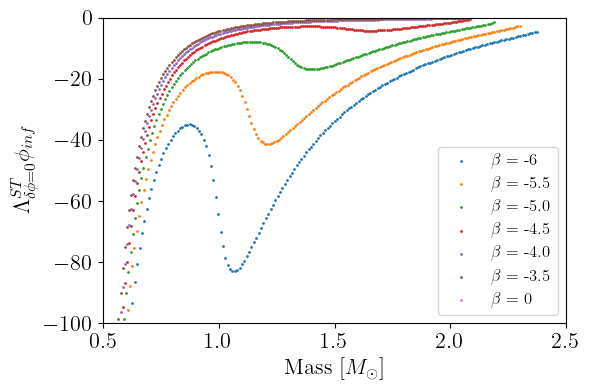

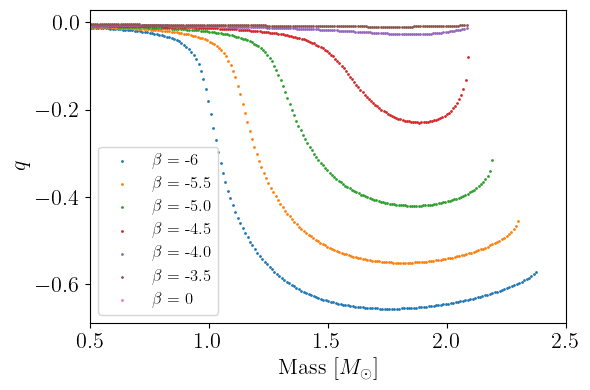

In [3]:
import jax.numpy as jnp                                                                                                    
import jax                                                                                                               
import matplotlib.pyplot as plt                                                                                            
import time                                                                                                                

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver

# Parameters
beta_values = [-6, -5.5, -5.0, -4.5, -4.0, -3.5, 0]
phi_c = 1.0
phi_inf_tgt = 1e-3

# Create EOSData (assuming ns, ps, hs, es, dloge_dlogps, cs2 are defined)
eos_data = EOSData(
  ns=ns,
  ps=ps,
  hs=hs,
  es=es,
  dloge_dlogps=dloge_dlogps,
  cs2=cs2,
)

# Create solvers
gr_solver = GRTOVSolver()
st_solver = ScalarTensorTOVSolver()

print("Running vmap for scalar-tensor calculations...")

def solve_for_beta(beta_ST):
    family = st_solver.construct_family(
      eos_data,
      ndat=200,
      min_nsat=0.1,
      beta_ST=beta_ST,
      phi_c=phi_c,
      phi_inf_tgt=phi_inf_tgt
    )
    return family

beta_array = jnp.array(beta_values)

start_time = time.time()
solve_for_beta_vmapped = jax.vmap(solve_for_beta)
st_families = solve_for_beta_vmapped(beta_array)

st_masses = st_families.masses
st_radii = st_families.radii
st_lambdas = st_families.lambdas
st_extra = st_families.extra  # Dictionary with solver-specific fields

st_masses.block_until_ready()
end_time = time.time()
duration = end_time - start_time
print(f"Scalar-tensor calculations for {len(beta_values)} beta values finished in {duration:.4f} seconds.")

# Collect results - filter out NaN values
results = {}
r_max = 50  # km
for i, beta_ST in enumerate(beta_values):
    radii_km = st_radii[i]
    masses_solar = st_masses[i]
    lambdas = st_lambdas[i]
    
    # Access extra fields from the dict
    mask = (radii_km < r_max) & (radii_km > 5) & (masses_solar > 0.5) & jnp.isfinite(st_extra["lambda_S"][i])
    
    results[beta_ST] = {
      "masses": masses_solar[mask],
      "radii": radii_km[mask],
      "lambdas": lambdas[mask],
      "lambdas_S": st_extra["lambda_S"][i][mask],
      "lambdas_ST1": st_extra["lambda_ST1"][i][mask],
      "lambdas_ST2": st_extra["lambda_ST2"][i][mask],
      "qs": st_extra["q"][i][mask],
    }

# GR reference
gr_family = gr_solver.construct_family(eos_data, ndat=300, min_nsat=0.5)
gr_mask = (gr_family.radii < r_max) & (gr_family.radii > 5) & (gr_family.masses > 0.5)
gr_masses = gr_family.masses[gr_mask]
gr_lambdas = gr_family.lambdas[gr_mask]

# ============================================
# Plot 1: Tensor tidal deformability Λ^T vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_masses, gr_lambdas, label='GR', color='black', linewidth=2)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^T$")
plt.ylim(0, 6000)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 2: Scalar tidal deformability Λ^S * φ_inf^2 vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_S"] * phi_inf_tgt**2, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^S \phi_{inf}^2$")
plt.ylim(0, 10)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 3: Mixed tidal deformability Λ^ST1 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST1"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{H_0 = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 4: Mixed tidal deformability Λ^ST2 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST2"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{\delta \phi = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 5: Scalar charge q vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
  plt.scatter(data["masses"], data["qs"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$q$")
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()
